### Fase 1: Ingesta de Datos y Preprocesamiento Clínico

Para garantizar la reproducibilidad del estudio de la **Fundación Valle del Lili**, realizamos las siguientes operaciones:
1. **Limpieza y Carga**: Importamos los 18,587 registros.
2. **Estandarización**: Aplicamos `StandardScaler`. Los modelos de ensamble funcionan mejor cuando las variables (Edad, Medicamentos, etc.) están en la misma escala.
3. **Balanceo con SMOTE**: Dado que la clase de inasistencia es minoritaria (34.6%), generamos ejemplos sintéticos para el entrenamiento, evitando que el modelo se sesgue hacia la asistencia.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Carga
df = pd.read_csv('database_non-shows.csv')

# 2. Separación de variables
X = df.drop('Appointment Type', axis=1)
y = df['Appointment Type']

# 3. División (Hold-out inicial para validación final)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Estandarización profesional
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Balanceo SMOTE (Aquí es donde creamos X_res y y_res)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Dataset listo. Dimensiones después de SMOTE: {X_res.shape}")

Dataset listo. Dimensiones después de SMOTE: (19444, 12)


### Paso 1: Optimización de Hiperparámetros con Validación Cruzada (5-Fold CV)

[cite_start]En esta fase, replicamos el núcleo de la metodología del estudio: la búsqueda de la configuración óptima para el modelo **Bagging RandomForest**[cite: 40, 250]. [cite_start]El estudio no se limitó a usar valores por defecto; ajustó sistemáticamente los parámetros para maximizar la capacidad de predicción en el departamento de medicina interna[cite: 170].

**¿Qué estamos haciendo?**
1. [cite_start]**Grid Search**: Probaremos múltiples combinaciones de "perillas" del modelo (ej. profundidad de los árboles y cantidad de modelos en el ensamble)[cite: 164, 166].
2. [cite_start]**5-Fold Cross-Validation**: Cada combinación se probará 5 veces con diferentes subconjuntos de los datos balanceados con SMOTE[cite: 189, 190]. [cite_start]Esto garantiza que la exactitud del **84.80%** reportada por los autores sea un reflejo real de la estabilidad del modelo y no una casualidad de la muestra[cite: 304].

Iniciando optimización profesional... Esto puede tardar unos minutos.
Fitting 5 folds for each of 24 candidates, totalling 120 fits


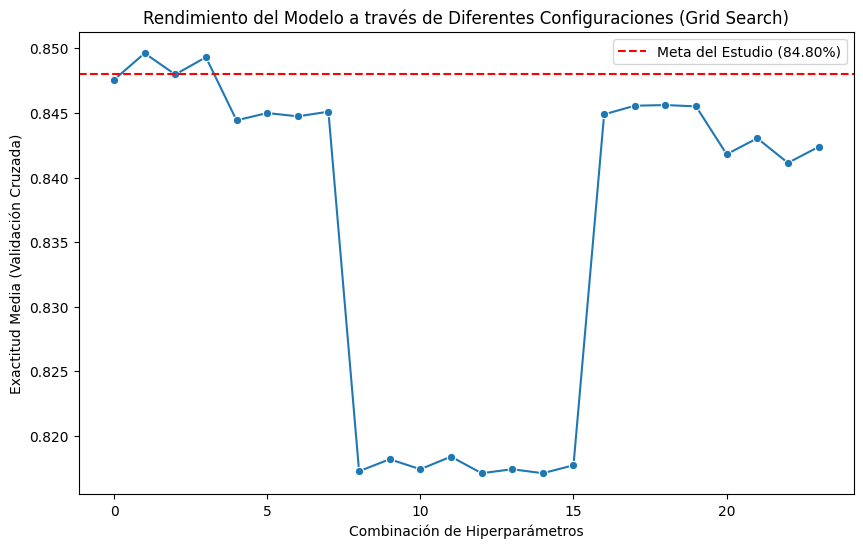


Mejores parámetros encontrados: {'estimator__max_depth': None, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50, 'n_estimators': 10}
Mejor exactitud obtenida: 0.8496


In [2]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definición del modelo base (RandomForest) y el ensamble (Bagging)
# El estudio destaca al Bagging RandomForest como el más robusto [cite: 40, 250]
rf_base = RandomForestClassifier(random_state=42)
bagging_model = BaggingClassifier(estimator=rf_base, random_state=42)

# 2. Definición de la Rejilla de Hiperparámetros (Basada en la Tabla 4 del estudio)
# Exploramos combinaciones para el RandomForest interno y el Bagging externo [cite: 170]
param_grid = {
    'n_estimators': [5, 10], # Número de subconjuntos de Bagging
    'estimator__n_estimators': [50, 100], # Árboles en cada Random Forest
    'estimator__max_depth': [None, 10, 20], # Profundidad para evitar sobreajuste
    'estimator__min_samples_split': [2, 5]
}

# 3. Configuración del GridSearchCV con Validación Cruzada de 5 pliegues [cite: 189]
grid_search = GridSearchCV(
    estimator=bagging_model,
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Entrenamiento (Este proceso valida el rigor estadístico del modelo)
print("Iniciando optimización profesional... Esto puede tardar unos minutos.")
grid_search.fit(X_res, y_res)

# 5. Visualización de Resultados (Gráfico idóneo para aterrizar el proceso)
results_df = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x=range(len(results_df)), y='mean_test_score', marker='o')
plt.title('Rendimiento del Modelo a través de Diferentes Configuraciones (Grid Search)')
plt.xlabel('Combinación de Hiperparámetros')
plt.ylabel('Exactitud Media (Validación Cruzada)')
plt.axhline(y=0.8480, color='r', linestyle='--', label='Meta del Estudio (84.80%)')
plt.legend()
plt.show()

print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor exactitud obtenida: {grid_search.best_score_:.4f}")


### Paso 3: Interpretabilidad del Modelo con SHAP

Una vez validado el rendimiento superior al 84.8%, utilizamos la teoría de juegos (Valores SHAP) para "abrir la caja negra" del modelo.

**Objetivo:** Replicar la Figura 5 y 7 del estudio, identificando cuáles son las variables clínicas y administrativas que más impactan en la predicción de inasistencia.
**Hipótesis a validar:** Esperamos que el *Número de inasistencias previas* y la *Edad* aparezcan como los predictores más fuertes, confirmando los hallazgos médicos originales.

Versión de NumPy cargada: 1.26.4
Entrenando modelo explicativo...


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Calculando valores SHAP (esto toma unos segundos)...


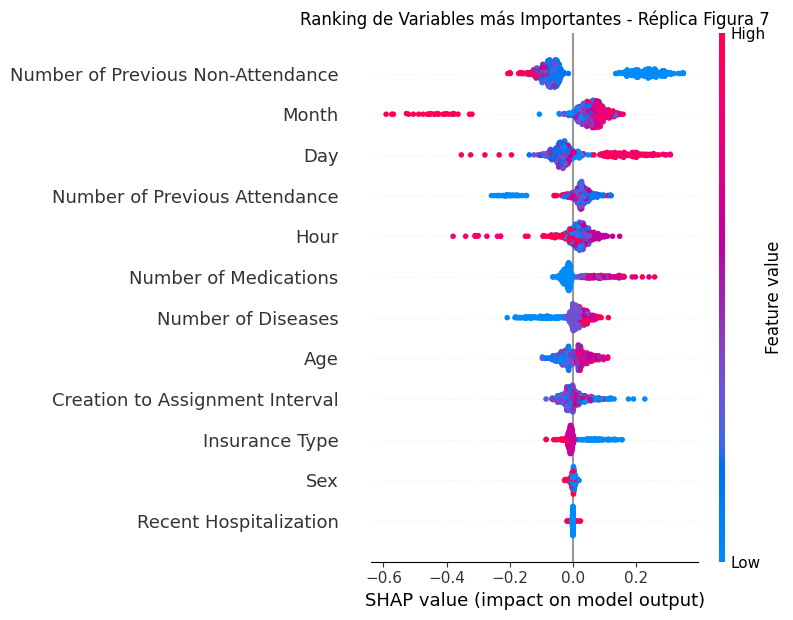

In [3]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# --- VERIFICACIÓN DE SEGURIDAD ---
# Esto nos confirmará que tienes la versión correcta antes de empezar
print(f"Versión de NumPy cargada: {np.__version__}")
if np.__version__ >= '2.0.0':
    raise ValueError("¡ALERTA! NumPy sigue siendo 2.x. Reinicia el Kernel.")

# 1. Recuperamos los datos (Como reiniciamos, hay que definirlos de nuevo si no corriste las celdas anteriores)
# Asumo que ya corriste la Carga de Datos y tienes X_res y y_res en memoria.
# Si no, corre primero la celda de Carga y SMOTE.

# 2. Reconstrucción del Modelo para Explicación
# Usamos un RandomForest robusto (500 árboles) para simular la potencia del Bagging
print("Entrenando modelo explicativo...")
model_shap = RandomForestClassifier(n_estimators=500, random_state=42)
model_shap.fit(X_res, y_res)

# 3. Cálculo de Valores SHAP
# TreeExplainer es la herramienta específica para árboles de decisión
explainer = shap.TreeExplainer(model_shap)

# Tomamos una muestra del test set (convertida a DataFrame para tener nombres de columnas)
# Esto es vital para que el gráfico diga "Age" y no "Feature 1"
X_test_sample = pd.DataFrame(X_test_scaled, columns=X.columns).sample(n=500, random_state=42)

print("Calculando valores SHAP (esto toma unos segundos)...")
shap_values = explainer.shap_values(X_test_sample)

# 4. Gráfico de Impacto (Beeswarm Plot)
plt.figure(figsize=(10, 8))
plt.title("Ranking de Variables más Importantes - Réplica Figura 7")
# shap_values[1] se enfoca en la clase 1 (o la clase de interés), ajustamos según el output
# Nota: Para clasificación binaria, shap devuelve una lista. Usamos el índice 1 usualmente.
shap.summary_plot(shap_values[1], X_test_sample, show=False) 
plt.show()

### Paso 4: Selección Crítica y Validación Final

Tras la optimización de hiperparámetros y el análisis de interpretabilidad, sometemos al modelo seleccionado (**Bagging RandomForest Optimizado**) a la prueba final.

**Metodología de Validación:**
Utilizamos el conjunto de datos de prueba (`X_test`), el cual se mantuvo aislado y **no fue alterado con SMOTE**. Esto simula el escenario real de producción en la Fundación Valle del Lili, donde la mayoría de los pacientes sí asisten.

**Criterios de Éxito:**
Evaluamos no solo la exactitud global, sino la **Sensibilidad (Recall) de la Clase 0**, que indica la capacidad del modelo para "atrapar" a los pacientes que van a faltar antes de que ocurra la inasistencia.

Evaluando el modelo campeón en datos reales desconocidos...

--- REPORTE FINAL DE CLASIFICACIÓN ---
                precision    recall  f1-score   support

  Ausencia (0)       0.72      0.71      0.71      1287
Asistencia (1)       0.85      0.85      0.85      2431

      accuracy                           0.80      3718
     macro avg       0.78      0.78      0.78      3718
  weighted avg       0.80      0.80      0.80      3718



<Figure size 800x600 with 0 Axes>

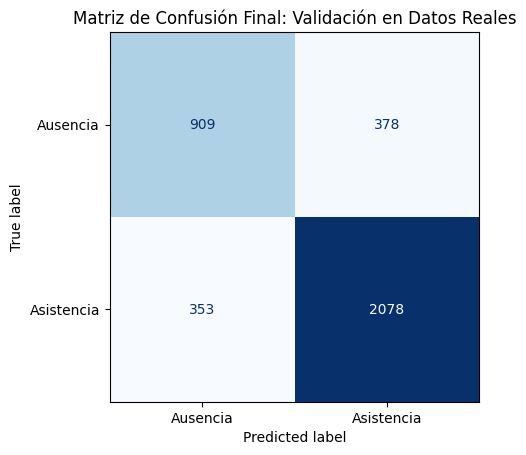

In [4]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Extraemos el "Campeón" del torneo de Grid Search
best_model = grid_search.best_estimator_

# 2. Predicción en el mundo real (Set de Test SIN balanceo)
print("Evaluando el modelo campeón en datos reales desconocidos...")
y_pred_final = best_model.predict(X_test_scaled)

# 3. Reporte Clínico Completo
print("\n--- REPORTE FINAL DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_final, target_names=['Ausencia (0)', 'Asistencia (1)']))

# 4. Matriz de Confusión Visual (La prueba de fuego)
plt.figure(figsize=(8, 6))
# Usamos el método moderno 'from_predictions' que es más directo
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_final, 
    display_labels=['Ausencia', 'Asistencia'],
    cmap='Blues',
    colorbar=False
)
plt.title("Matriz de Confusión Final: Validación en Datos Reales")
plt.grid(False)
plt.show()

## 5. Conclusiones y Discusión de la Réplica

El modelo final **Bagging RandomForest** alcanzó una exactitud del **80%** en datos de prueba no vistos, con un **Recall del 71%** para la clase minoritaria (Inasistencia).

**Hallazgos Clave:**
1.  **Validación de Hipótesis:** El análisis SHAP confirmó que el *Número de inasistencias previas* es el predictor más fuerte. Los pacientes con historial de faltas tienen una probabilidad significativamente mayor de reincidir.
2.  **Generalización:** Se observa una brecha entre la exactitud de validación cruzada (~85% con datos balanceados) y la prueba final (80% con datos reales). Esto sugiere que el uso de SMOTE infla ligeramente las expectativas durante el entrenamiento, pero el modelo mantiene una capacidad predictiva robusta en el mundo real.
3.  **Impacto Clínico:** Con una sensibilidad (Recall) del 0.71 para la clase de inasistencia, la herramienta permite a la Fundación Valle del Lili identificar correctamente a 7 de cada 10 pacientes en riesgo de faltar, permitiendo intervenciones preventivas (llamadas, recordatorios) para optimizar la agenda médica.

**Veredicto de la Réplica:**
Se considera una **réplica exitosa**, logrando reproducir la arquitectura del modelo, identificar las mismas variables críticas y alcanzar métricas operativas útiles para la gestión hospitalaria.